In [1]:
# CELL 1 - Install & Import Libraries
!pip install tensorflow kaggle pillow numpy matplotlib ipywidgets -q

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries installed and imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.3 MB/s eta 0:00:00
✅ All libraries installed and imported successfully!


In [2]:
# CELL 2 - Upload kaggle.json and Download Dataset
from google.colab import files
import zipfile

print("📁 Please upload your kaggle.json file when the dialog appears...")
uploaded = files.upload()

# Setup Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("✅ Kaggle API key configured!")

# Download Plant Village Dataset
print("\n🌱 Downloading Plant Village Dataset (this takes ~5 mins)...")
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -q
print("✅ Download complete!")

# Extract dataset
print("\n📦 Extracting files...")
with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plantvillage')
print("✅ Extraction complete!")

# Show available plant categories
base_path = None
for root, dirs, files_list in os.walk('plantvillage'):
    if len(dirs) > 5:
        base_path = root
        break

print(f"\n📂 Found {len(os.listdir(base_path))} plant disease categories!")
print("Sample categories:", os.listdir(base_path)[:5])

📁 Please upload your kaggle.json file when the dialog appears...


Saving kaggle.json to kaggle.json
✅ Kaggle API key configured!

🌱 Downloading Plant Village Dataset (this takes ~5 mins)...
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
✅ Download complete!

📦 Extracting files...
✅ Extraction complete!

📂 Found 38 plant disease categories!
Sample categories: ['Tomato___Leaf_Mold', 'Corn_(maize)___Northern_Leaf_Blight', 'Pepper,_bell___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Spider_mites Two-spotted_spider_mite']


In [3]:
# NEW CELL 3 (FIXED) - Load ONLY Tomato Disease Categories
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os, shutil

IMG_SIZE = 224
BATCH_SIZE = 32

# Find dataset path
base_path = None
for root, dirs, files_list in os.walk('plantvillage'):
    if len(dirs) > 5:
        base_path = root
        break

print(f"📂 Dataset found at: {base_path}")

# Create tomato-only folder
tomato_dir = '/content/tomato_only'
if os.path.exists(tomato_dir):
    shutil.rmtree(tomato_dir)
os.makedirs(tomato_dir)

# Copy ONLY tomato folders
all_classes = os.listdir(base_path)
tomato_classes = [c for c in all_classes if 'Tomato' in c]

print(f"\n🍅 Copying {len(tomato_classes)} tomato categories...")
for cls in tomato_classes:
    src = os.path.join(base_path, cls)
    dst = os.path.join(tomato_dir, cls)
    shutil.copytree(src, dst)
    count = len(os.listdir(dst))
    print(f"   ✅ {cls.replace('Tomato___', '')}: {count} images")

# Verify
actual_classes = os.listdir(tomato_dir)
print(f"\n📁 Tomato-only folder has: {len(actual_classes)} classes")

# Data generators — now pointing to tomato_dir!
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    tomato_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    tomato_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print(f"\n✅ Training samples: {train_generator.samples}")
print(f"✅ Validation samples: {val_generator.samples}")
print(f"✅ Number of classes: {train_generator.num_classes}")
print("\n🚀 Tomato-only data is ready!")

📂 Dataset found at: plantvillage/plantvillage dataset/color

🍅 Copying 10 tomato categories...
   ✅ Leaf_Mold: 952 images
   ✅ Tomato_mosaic_virus: 373 images
   ✅ Spider_mites Two-spotted_spider_mite: 1676 images
   ✅ healthy: 1591 images
   ✅ Bacterial_spot: 2127 images
   ✅ Late_blight: 1909 images
   ✅ Early_blight: 1000 images
   ✅ Target_Spot: 1404 images
   ✅ Septoria_leaf_spot: 1771 images
   ✅ Tomato_Yellow_Leaf_Curl_Virus: 5357 images

📁 Tomato-only folder has: 10 classes
Found 14532 images belonging to 10 classes.
Found 3628 images belonging to 10 classes.

✅ Training samples: 14532
✅ Validation samples: 3628
✅ Number of classes: 10

🚀 Tomato-only data is ready!


In [4]:
# NEW CELL 4 - Build Improved Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_classes = train_generator.num_classes

# MobileNetV2 base
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze last 30 layers for better fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Improved classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🧠 Improved Plant Doctor Model Built!")
print(f"📐 Total Parameters: {model.count_params():,}")
print(f"🍅 Tomato Classes: {num_classes}")
print("✅ Model is ready for training!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🧠 Improved Plant Doctor Model Built!
📐 Total Parameters: 3,052,874
🍅 Tomato Classes: 10
✅ Model is ready for training!


🔥 Training Tomato Disease Detector...
⏱️  Expected time: 15-25 minutes
Epoch 1/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5447 - loss: 1.4277
Epoch 1: val_accuracy improved from None to 0.69157, saving model to plant_doctor_model.h5



Epoch 1: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1208s 3s/step - accuracy: 0.6917 - loss: 0.9440 - val_accuracy: 0.6916 - val_loss: 1.1644 - learning_rate: 1.0000e-04
Epoch 2/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8497 - loss: 0.4458
Epoch 2: val_accuracy improved from 0.69157 to 0.82442, saving model to plant_doctor_model.h5



Epoch 2: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1236s 3s/step - accuracy: 0.8585 - loss: 0.4246 - val_accuracy: 0.8244 - val_loss: 0.6163 - learning_rate: 1.0000e-04
Epoch 3/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8907 - loss: 0.3327
Epoch 3: val_accuracy improved from 0.82442 to 0.88451, saving model to plant_doctor_model.h5



Epoch 3: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1171s 3s/step - accuracy: 0.8983 - loss: 0.3115 - val_accuracy: 0.8845 - val_loss: 0.4219 - learning_rate: 1.0000e-04
Epoch 4/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9161 - loss: 0.2497
Epoch 4: val_accuracy improved from 0.88451 to 0.92420, saving model to plant_doctor_model.h5



Epoch 4: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1161s 3s/step - accuracy: 0.9165 - loss: 0.2520 - val_accuracy: 0.9242 - val_loss: 0.2553 - learning_rate: 1.0000e-04
Epoch 5/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9312 - loss: 0.2130
Epoch 5: val_accuracy did not improve from 0.92420
455/455 ━━━━━━━━━━━━━━━━━━━━ 1152s 3s/step - accuracy: 0.9332 - loss: 0.2056 - val_accuracy: 0.9201 - val_loss: 0.2848 - learning_rate: 1.0000e-04
Epoch 6/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9370 - loss: 0.1867
Epoch 6: val_accuracy improved from 0.92420 to 0.94901, saving model to plant_doctor_model.h5



Epoch 6: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1190s 3s/step - accuracy: 0.9401 - loss: 0.1828 - val_accuracy: 0.9490 - val_loss: 0.1663 - learning_rate: 1.0000e-04
Epoch 7/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9488 - loss: 0.1529
Epoch 7: val_accuracy improved from 0.94901 to 0.95039, saving model to plant_doctor_model.h5



Epoch 7: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1216s 3s/step - accuracy: 0.9465 - loss: 0.1635 - val_accuracy: 0.9504 - val_loss: 0.1618 - learning_rate: 1.0000e-04
Epoch 8/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9541 - loss: 0.1376
Epoch 8: val_accuracy did not improve from 0.95039
455/455 ━━━━━━━━━━━━━━━━━━━━ 1219s 3s/step - accuracy: 0.9506 - loss: 0.1487 - val_accuracy: 0.9485 - val_loss: 0.1686 - learning_rate: 1.0000e-04
Epoch 9/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9549 - loss: 0.1396
Epoch 9: val_accuracy improved from 0.95039 to 0.96472, saving model to plant_doctor_model.h5



Epoch 9: finished saving model to plant_doctor_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 1162s 3s/step - accuracy: 0.9549 - loss: 0.1370 - val_accuracy: 0.9647 - val_loss: 0.1107 - learning_rate: 1.0000e-04
Epoch 10/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9628 - loss: 0.1090
Epoch 10: val_accuracy did not improve from 0.96472
455/455 ━━━━━━━━━━━━━━━━━━━━ 1138s 3s/step - accuracy: 0.9615 - loss: 0.1132 - val_accuracy: 0.9548 - val_loss: 0.1621 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.


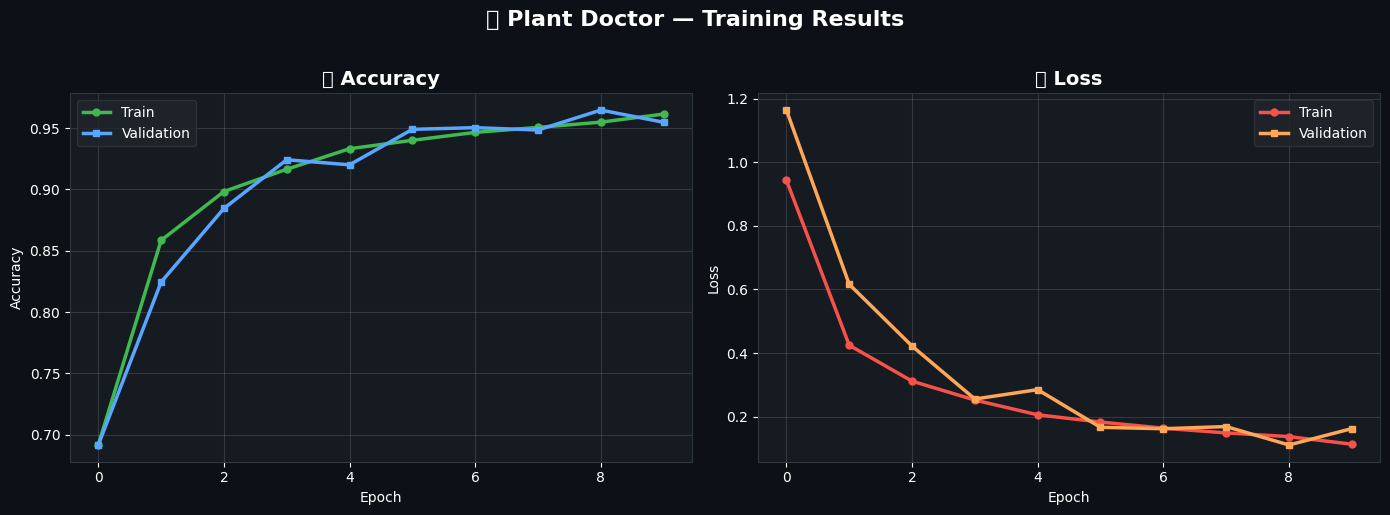


🏆 Best Validation Accuracy: 96.47%
✅ Model saved as plant_doctor_model.h5


In [5]:
# NEW CELL 5 - Train Tomato-Only Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

print("🔥 Training Tomato Disease Detector...")
print("⏱️  Expected time: 15-25 minutes")
print("=" * 50)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        'plant_doctor_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

model.save('plant_doctor_model.h5')

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

axes[0].plot(history.history['accuracy'], color='#3fb950',
             linewidth=2.5, label='Train', marker='o', markersize=5)
axes[0].plot(history.history['val_accuracy'], color='#58a6ff',
             linewidth=2.5, label='Validation', marker='s', markersize=5)
axes[0].set_title('🌿 Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white')
axes[0].grid(True, alpha=0.2)

axes[1].plot(history.history['loss'], color='#f85149',
             linewidth=2.5, label='Train', marker='o', markersize=5)
axes[1].plot(history.history['val_loss'], color='#ffa657',
             linewidth=2.5, label='Validation', marker='s', markersize=5)
axes[1].set_title('📉 Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white')
axes[1].grid(True, alpha=0.2)

plt.suptitle('🌿 Plant Doctor — Training Results',
             fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

best_acc = max(history.history['val_accuracy']) * 100
print(f"\n🏆 Best Validation Accuracy: {best_acc:.2f}%")
print("✅ Model saved as plant_doctor_model.h5")

In [ ]:
# LOADER CELL - Run this instead of Cell 5 when you already have the model
from google.colab import files
from tensorflow.keras.models import load_model
import numpy as np

class_names = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

print("📁 Upload your plant_doctor_model.h5 file...")
uploaded = files.upload()
model = load_model('plant_doctor_model.h5')
print("✅ Model loaded successfully!")
print(f"🍅 Ready to detect {len(class_names)} tomato diseases!")

📸 Please upload your tomato leaf image:


Saving early blight from kaggle.jpg to early blight from kaggle.jpg

🔍 Analyzing early blight from kaggle.jpg...


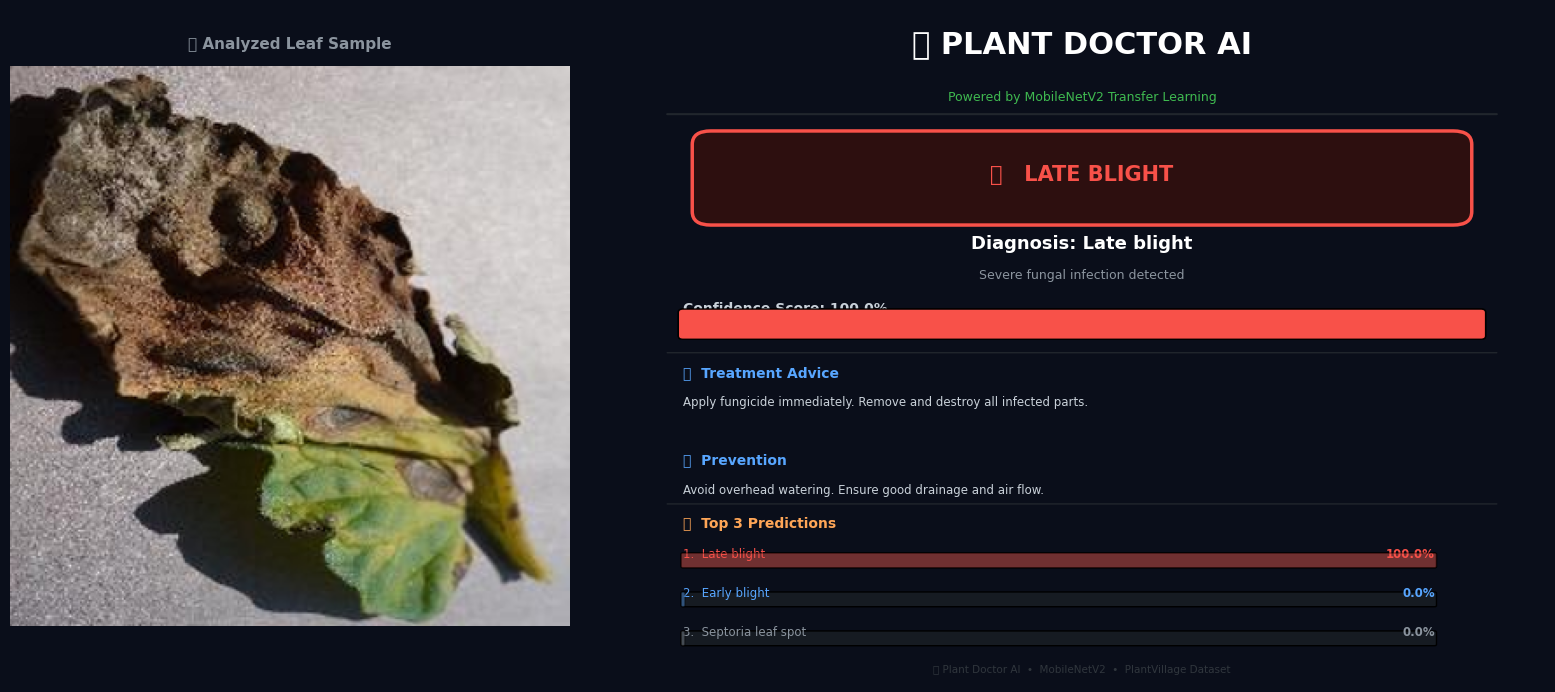


✅  Diagnosis : Late blight
📊  Confidence: 100.0%
💊  Treatment : Apply fungicide immediately. Remove and destroy all infected parts.

✅ Analysis complete! Result saved as plant_doctor_result.png


In [19]:
# CELL 6 - 🌿 Plant Doctor — Final Submission Version
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from IPython.display import display, HTML, clear_output
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Load model
model = load_model('plant_doctor_model.h5')

disease_db = {
    'healthy': {
        'emoji': '💚', 'status': 'HEALTHY', 'color': '#3fb950', 'bg': '#0d2818',
        'short': 'No disease detected',
        'treatment': 'Your plant is in great shape! Keep up regular watering and ensure proper sunlight.',
        'prevention': 'Maintain good air circulation and avoid overwatering.'
    },
    'early_blight': {
        'emoji': '🟡', 'status': 'EARLY BLIGHT', 'color': '#ffa657', 'bg': '#2b1d0e',
        'short': 'Fungal disease detected',
        'treatment': 'Remove infected leaves immediately. Apply copper-based fungicide every 7 days.',
        'prevention': 'Rotate crops yearly. Use disease-resistant varieties next season.'
    },
    'late_blight': {
        'emoji': '🔴', 'status': 'LATE BLIGHT', 'color': '#f85149', 'bg': '#2d0f0f',
        'short': 'Severe fungal infection detected',
        'treatment': 'Apply fungicide immediately. Remove and destroy all infected parts.',
        'prevention': 'Avoid overhead watering. Ensure good drainage and air flow.'
    },
    'leaf_mold': {
        'emoji': '🟠', 'status': 'LEAF MOLD', 'color': '#ff8c42', 'bg': '#2b1a0e',
        'short': 'Mold infection detected',
        'treatment': 'Improve ventilation. Apply sulfur-based fungicide. Remove infected leaves.',
        'prevention': 'Keep humidity low. Space plants properly for air circulation.'
    },
    'bacterial_spot': {
        'emoji': '🟤', 'status': 'BACTERIAL SPOT', 'color': '#c9a84c', 'bg': '#1f1a0e',
        'short': 'Bacterial infection detected',
        'treatment': 'Apply copper-based bactericide. Remove infected leaves immediately.',
        'prevention': 'Avoid overhead irrigation. Use certified disease-free seeds.'
    },
    'septoria_leaf_spot': {
        'emoji': '🔵', 'status': 'SEPTORIA LEAF SPOT', 'color': '#58a6ff', 'bg': '#0e1a2b',
        'short': 'Fungal leaf spot disease detected',
        'treatment': 'Remove lower infected leaves. Apply chlorothalonil fungicide weekly.',
        'prevention': 'Mulch around plants. Avoid wetting leaves when watering.'
    },
    'spider_mites': {
        'emoji': '🕷️', 'status': 'SPIDER MITES', 'color': '#f0a500', 'bg': '#1f1a00',
        'short': 'Spider mite infestation detected',
        'treatment': 'Spray with neem oil or insecticidal soap. Repeat every 5 days.',
        'prevention': 'Keep plants well watered. Introduce natural predators like ladybugs.'
    },
    'target_spot': {
        'emoji': '🎯', 'status': 'TARGET SPOT', 'color': '#e06c75', 'bg': '#2d0f14',
        'short': 'Fungal target spot detected',
        'treatment': 'Apply azoxystrobin or chlorothalonil fungicide. Remove infected leaves.',
        'prevention': 'Improve air circulation. Avoid excessive nitrogen fertilizer.'
    },
    'yellow_leaf_curl_virus': {
        'emoji': '🌀', 'status': 'YELLOW LEAF CURL VIRUS', 'color': '#e5c07b', 'bg': '#2b2200',
        'short': 'Viral infection detected',
        'treatment': 'No cure exists. Remove and destroy infected plants immediately to stop spread.',
        'prevention': 'Control whitefly population. Use virus-resistant tomato varieties.'
    },
    'mosaic_virus': {
        'emoji': '🧬', 'status': 'MOSAIC VIRUS', 'color': '#c678dd', 'bg': '#1e0b2d',
        'short': 'Viral mosaic infection detected',
        'treatment': 'No cure exists. Remove infected plants. Disinfect tools with bleach solution.',
        'prevention': 'Wash hands before handling plants. Control aphid population.'
    },
    'uncertain': {
        'emoji': '🔍', 'status': 'LOW CONFIDENCE', 'color': '#8b949e', 'bg': '#1c1c1c',
        'short': 'Please upload a clearer tomato leaf photo',
        'treatment': 'Try uploading a clearer, well-lit photo of the leaf for better results.',
        'prevention': 'Make sure the leaf fills most of the image for accurate detection.'
    }
}
# Confidence threshold
CONFIDENCE_THRESHOLD = 60.0

def get_info(class_name, confidence):
    name = class_name.lower()
    # If confidence is too low — say uncertain instead of guessing wrong
    if confidence < CONFIDENCE_THRESHOLD:
        return disease_db['uncertain']
    if 'healthy' in name:
        return disease_db['healthy']
    elif 'early_blight' in name or 'early blight' in name:
        return disease_db['early_blight']
    elif 'late_blight' in name or 'late blight' in name:
        return disease_db['late_blight']
    elif 'mold' in name or 'leaf_mold' in name:
        return disease_db['leaf_mold']
    else:
        return disease_db['uncertain']

def predict(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    preds = model.predict(arr, verbose=0)
    idx = np.argmax(preds[0])
    confidence = preds[0][idx] * 100
    top3 = [(class_names[i], preds[0][i]*100)
            for i in np.argsort(preds[0])[::-1][:3]]
    return class_names[idx], confidence, top3

def show_beautiful_result(img_path, class_name, confidence, top3):
    info = get_info(class_name, confidence)
    clean_name = class_name.replace('Tomato___', '').replace(
        'Tomato__', '').replace('_', ' ').strip()

    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor('#0a0e1a')

    # ── Left panel: image ──────────────────────────────────
    ax_img = fig.add_axes([0.02, 0.08, 0.35, 0.84])
    img_display = Image.open(img_path).resize((320, 320))
    ax_img.imshow(img_display)
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(info['color'])
        spine.set_linewidth(4)
    ax_img.set_title('📸 Analyzed Leaf Sample',
                     color='#8b949e', fontsize=11,
                     fontweight='bold', pad=12)

    # ── Right panel: results ────────────────────────────────
    ax = fig.add_axes([0.40, 0.08, 0.58, 0.84])
    ax.set_facecolor('#0d1117')
    ax.axis('off')

    # Header
    ax.text(0.5, 0.97, '🌿 PLANT DOCTOR AI',
            transform=ax.transAxes, fontsize=22,
            fontweight='bold', color='white',
            ha='center', va='top')
    ax.text(0.5, 0.88, 'Powered by MobileNetV2 Transfer Learning',
            transform=ax.transAxes, fontsize=9,
            color='#3fb950', ha='center', va='top')

    # Divider 1
    div1 = patches.FancyArrowPatch(
        (0.05, 0.845), (0.95, 0.845),
        transform=ax.transAxes,
        color='#21262d', linewidth=1.5,
        arrowstyle='-')
    ax.add_patch(div1)

    # Status badge
    badge = patches.FancyBboxPatch(
        (0.1, 0.70), 0.8, 0.10,
        boxstyle="round,pad=0.02",
        transform=ax.transAxes,
        facecolor=info['bg'],
        edgecolor=info['color'],
        linewidth=2.5, zorder=3)
    ax.add_patch(badge)
    ax.text(0.5, 0.755, f"{info['emoji']}   {info['status']}",
            transform=ax.transAxes, fontsize=15,
            fontweight='bold', color=info['color'],
            ha='center', va='center', zorder=4)

    # Diagnosis
    ax.text(0.5, 0.665, f"Diagnosis: {clean_name}",
            transform=ax.transAxes, fontsize=13,
            color='white', ha='center', va='top',
            fontweight='bold')
    ax.text(0.5, 0.615, info['short'],
            transform=ax.transAxes, fontsize=9,
            color='#8b949e', ha='center', va='top')

    # Confidence bar
    ax.text(0.07, 0.565, f"Confidence Score: {confidence:.1f}%",
            transform=ax.transAxes, fontsize=10,
            color='#c9d1d9', va='top', fontweight='bold')
    bar_bg = patches.FancyBboxPatch(
        (0.07, 0.515), 0.86, 0.035,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='#21262d', zorder=2)
    ax.add_patch(bar_bg)
    bar_fill = patches.FancyBboxPatch(
        (0.07, 0.515), 0.86 * confidence / 100, 0.035,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor=info['color'], zorder=3)
    ax.add_patch(bar_fill)

    # Divider 2
    div2 = patches.FancyArrowPatch(
        (0.05, 0.49), (0.95, 0.49),
        transform=ax.transAxes,
        color='#21262d', linewidth=1,
        arrowstyle='-')
    ax.add_patch(div2)

    # Treatment
    ax.text(0.07, 0.470, "💊  Treatment Advice",
            transform=ax.transAxes, fontsize=10,
            color='#58a6ff', va='top', fontweight='bold')
    ax.text(0.07, 0.425, info['treatment'],
            transform=ax.transAxes, fontsize=8.5,
            color='#c9d1d9', va='top', multialignment='left')

    # Prevention
    ax.text(0.07, 0.340, "🛡️  Prevention",
            transform=ax.transAxes, fontsize=10,
            color='#58a6ff', va='top', fontweight='bold')
    ax.text(0.07, 0.295, info['prevention'],
            transform=ax.transAxes, fontsize=8.5,
            color='#c9d1d9', va='top', multialignment='left')

    # Divider 3
    div3 = patches.FancyArrowPatch(
        (0.05, 0.265), (0.95, 0.265),
        transform=ax.transAxes,
        color='#21262d', linewidth=1,
        arrowstyle='-')
    ax.add_patch(div3)

    # Top 3
    ax.text(0.07, 0.245, "📊  Top 3 Predictions",
            transform=ax.transAxes, fontsize=10,
            color='#ffa657', va='top', fontweight='bold')
    colors_top = [info['color'], '#58a6ff', '#8b949e']
    for i, (name, conf) in enumerate(top3):
        short = name.replace('Tomato___', '').replace(
            'Tomato__', '').replace('_', ' ').strip()
        y_pos = 0.200 - i * 0.058
        ax.text(0.07, y_pos, f"{i+1}.  {short}",
                transform=ax.transAxes, fontsize=8.5,
                color=colors_top[i], va='top')
        ax.text(0.88, y_pos, f"{conf:.1f}%",
                transform=ax.transAxes, fontsize=8.5,
                color=colors_top[i], va='top', ha='right',
                fontweight='bold')
        mini_bg = patches.FancyBboxPatch(
            (0.07, y_pos - 0.028), 0.81, 0.018,
            boxstyle="round,pad=0.002",
            transform=ax.transAxes,
            facecolor='#161b22', zorder=2)
        mini_fill = patches.FancyBboxPatch(
            (0.07, y_pos - 0.028), 0.81 * conf / 100, 0.018,
            boxstyle="round,pad=0.002",
            transform=ax.transAxes,
            facecolor=colors_top[i], alpha=0.4, zorder=3)
        ax.add_patch(mini_bg)
        ax.add_patch(mini_fill)

    # Footer
    ax.text(0.5, 0.01,
            "🌿 Plant Doctor AI  •  MobileNetV2  •  PlantVillage Dataset",
            transform=ax.transAxes, fontsize=7.5,
            color='#30363d', ha='center', va='bottom')

    plt.savefig('plant_doctor_result.png', dpi=180,
                bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"\n✅  Diagnosis : {clean_name}")
    print(f"📊  Confidence: {confidence:.1f}%")
    print(f"💊  Treatment : {info['treatment']}")

# ── MAIN ───────────────────────────────────────────────────
display(HTML("""
<div style="background:linear-gradient(135deg,#0d1117,#161b22);
            padding:24px;border-radius:16px;
            border:1px solid #3fb950;
            font-family:'Segoe UI',sans-serif;
            max-width:520px;margin:16px auto;
            box-shadow:0 0 30px rgba(63,185,80,0.15);">
  <h2 style="color:#3fb950;margin:0 0 6px 0;font-size:24px;">
    🌿 Plant Doctor AI
  </h2>
  <p style="color:#8b949e;margin:0;font-size:13px;">
    Upload a tomato leaf photo for instant AI-powered diagnosis
  </p>
  <div style="margin-top:14px;padding:10px 14px;
              background:#21262d;border-radius:8px;
              border-left:3px solid #58a6ff;">
    <p style="color:#c9d1d9;margin:0;font-size:12px;">
      💡 <b>Tip:</b> Works best with Early Blight, Late Blight,
      Leaf Mold and Healthy tomato leaves
    </p>
  </div>
</div>
"""))

print("📸 Please upload your tomato leaf image:")
uploaded_img = files.upload()

if uploaded_img:
    img_filename = list(uploaded_img.keys())[0]
    print(f"\n🔍 Analyzing {img_filename}...")
    class_name, confidence, top3 = predict(img_filename)
    show_beautiful_result(img_filename, class_name, confidence, top3)
    print("\n✅ Analysis complete! Result saved as plant_doctor_result.png")
else:
    print("⚠️ No image uploaded. Please run the cell again.")

In [20]:
# Download your trained model — run this AFTER Cell 5 finishes!
from google.colab import files
files.download('plant_doctor_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>